In [21]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, spectrogram
import pywt
import mne
import pandas as pd
import os

In [22]:
# Укажите точное имя вашего EDF-файла и файла аннотаций
edf_filename = 'eeg1.edf'  # Замените, если скачали другой файл
annotations_filename = 'annotations_2017_A.csv'

# Проверка наличия файлов
if not os.path.exists(edf_filename):
    raise FileNotFoundError(f"Файл {edf_filename} не найден. Загрузите его в Colab.")
if not os.path.exists(annotations_filename):
    raise FileNotFoundError(f"Файл {annotations_filename} не найден. Загрузите его в Colab.")

print(f"Загрузка файла ЭЭГ: {edf_filename}")
raw = mne.io.read_raw_edf(edf_filename, preload=True)

# Базовая информация о записи
print(f"Частота дискретизации: {raw.info['sfreq']} Гц")
print(f"Количество каналов: {len(raw.ch_names)}")
print(f"Длительность записи: {raw.times[-1]:.2f} с")
print(f"Названия каналов: {raw.ch_names}")

# Загрузка файла аннотаций
print(f"\nЗагрузка файла аннотаций: {annotations_filename}")
annotations_df = pd.read_csv(annotations_filename)
print(f"Аннотации загружены. Количество записей: {len(annotations_df)}")
annotations_df.head()  # Покажем первые строки для проверки

Загрузка файла ЭЭГ: eeg1.edf
Extracting EDF parameters from eeg1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1790207  =      0.000 ...  6992.996 secs...
Частота дискретизации: 256.0 Гц
Количество каналов: 21
Длительность записи: 6993.00 с
Названия каналов: ['EEG Fp1-REF', 'EEG Fp2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG Fz-REF', 'EEG Cz-REF', 'EEG Pz-REF', 'ECG EKG-REF', 'Resp Effort-REF']

Загрузка файла аннотаций: annotations_2017_A.csv
Аннотации загружены. Количество записей: 15416


,1,2,3,4,5,6,7,8,9,10,...,70,71,72,73,74,75,76,77,78,79
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
# Укажите точное имя вашего EDF-файла и файла аннотаций
edf_filename = 'eeg1.edf'  # Замените, если скачали другой файл
annotations_filename = 'annotations_2017_A.csv'

# Проверка наличия файлов
if not os.path.exists(edf_filename):
    raise FileNotFoundError(f"Файл {edf_filename} не найден. Загрузите его в Colab.")
if not os.path.exists(annotations_filename):
    raise FileNotFoundError(f"Файл {annotations_filename} не найден. Загрузите его в Colab.")

print(f"Загрузка файла ЭЭГ: {edf_filename}")
raw = mne.io.read_raw_edf(edf_filename, preload=True)

# Базовая информация о записи
print(f"Частота дискретизации: {raw.info['sfreq']} Гц")
print(f"Количество каналов: {len(raw.ch_names)}")
print(f"Длительность записи: {raw.times[-1]:.2f} с")
print(f"Названия каналов: {raw.ch_names}")

# Загрузка файла аннотаций
print(f"\nЗагрузка файла аннотаций: {annotations_filename}")
annotations_df = pd.read_csv(annotations_filename)

# ВАЖНО: Выводим информацию о структуре файла
print("\n=== СТРУКТУРА ФАЙЛА АННОТАЦИЙ ===")
print(f"Размер таблицы: {annotations_df.shape}")
print(f"Названия колонок: {list(annotations_df.columns[:5])}... (показаны первые 5)")
print(f"Первые 3 значения в первой колонке: {annotations_df.iloc[:3, 0].tolist()}")
print("\nПервые 5 строк файла аннотаций:")
display(annotations_df.head())
print("=" * 50)

Загрузка файла ЭЭГ: eeg1.edf
Extracting EDF parameters from eeg1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1790207  =      0.000 ...  6992.996 secs...
Частота дискретизации: 256.0 Гц
Количество каналов: 21
Длительность записи: 6993.00 с
Названия каналов: ['EEG Fp1-REF', 'EEG Fp2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG Fz-REF', 'EEG Cz-REF', 'EEG Pz-REF', 'ECG EKG-REF', 'Resp Effort-REF']

Загрузка файла аннотаций: annotations_2017_A.csv

=== СТРУКТУРА ФАЙЛА АННОТАЦИЙ ===
Размер таблицы: (15416, 79)
Названия колонок: ['1', '2', '3', '4', '5']... (показаны первые 5)
Первые 3 значения в первой колонке: [0.0, 0.0, 0.0]

Первые 5 строк файла аннотаций:


,1,2,3,4,5,6,7,8,9,10,...,70,71,72,73,74,75,76,77,78,79
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import re

# Извлекаем номер из имени EDF-файла (например, из 'eeg1.edf' -> '1')
match = re.search(r'(\d+)', edf_filename)
if match:
    file_number = match.group(1)  # Номер файла как строка
    print(f"Извлечен номер файла: {file_number}")
else:
    raise ValueError(f"Не удалось извлечь номер из имени файла '{edf_filename}'")

# Проверяем, есть ли такая колонка в аннотациях
if file_number not in annotations_df.columns:
    print(f"Ошибка: колонка с номером '{file_number}' не найдена!")
    print(f"Доступные колонки (первые 10): {list(annotations_df.columns[:10])}")
    raise KeyError(f"Колонка '{file_number}' отсутствует в аннотациях")

print(f"Колонка '{file_number}' найдена в аннотациях.")

# Извлекаем данные для нашего файла
seizure_labels_all = annotations_df[file_number].values  # Все значения включая NaN
print(f"Общая длина массива меток: {len(seizure_labels_all)}")

# ВАЖНО: Отфильтровываем NaN значения
# Находим индексы, где значения не NaN
valid_mask = ~pd.isna(seizure_labels_all)
seizure_labels = seizure_labels_all[valid_mask]
print(f"Количество не-NaN значений: {len(seizure_labels)}")
print(f"Количество NaN значений: {len(seizure_labels_all) - len(seizure_labels)}")

# ВАЖНО: В этом датасете каждая строка соответствует 1 секунде
annotation_fs = 1.0  # 1 отсчет в секунду
print(f"Частота аннотаций: {annotation_fs} Гц (каждая строка = 1 секунда)")

# Создаем массив времени для валидных аннотаций
annotation_times = np.arange(len(seizure_labels)) / annotation_fs
print(f"Временной диапазон аннотаций: 0 - {annotation_times[-1]:.1f} с")
print(f"Длительность записи ЭЭГ: {raw.times[-1]:.1f} с")

# Проверяем соответствие длительности
if abs(annotation_times[-1] - raw.times[-1]) > 10:
    print(f"⚠️ Предупреждение: Длительность аннотаций ({annotation_times[-1]:.0f} с) не совпадает с длительностью ЭЭГ ({raw.times[-1]:.0f} с)")

# Находим индексы, где есть приступ (значение = 1)
seizure_indices = np.where(seizure_labels == 1)[0]

if len(seizure_indices) == 0:
    print(f"\n⚠️ Внимание: Файл {edf_filename} не содержит приступов (все метки = 0).")
    print("Ищем другой файл с приступами...")

    # Ищем любую колонку, где есть хотя бы одна единица
    has_seizure = (annotations_df == 1).any()
    seizure_columns = has_seizure[has_seizure].index.tolist()

    if seizure_columns:
        # Выбираем первый попавшийся файл с приступом
        for col in seizure_columns:
            temp_labels = annotations_df[col].dropna().values
            if 1 in temp_labels:
                file_number = col
                seizure_labels_all = annotations_df[file_number].values
                valid_mask = ~pd.isna(seizure_labels_all)
                seizure_labels = seizure_labels_all[valid_mask]
                seizure_indices = np.where(seizure_labels == 1)[0]
                annotation_times = np.arange(len(seizure_labels)) / annotation_fs
                print(f"Выбран файл с номером {file_number}")
                print(f"Количество не-NaN значений: {len(seizure_labels)}")
                print(f"Найдено {len(seizure_indices)} временных точек с приступом")
                break
    else:
        raise ValueError("В датасете не найдено ни одного файла с приступом!")

print(f"\nКоличество временных точек с приступом: {len(seizure_indices)}")

# Определяем непрерывные интервалы приступа
seizure_starts = []
seizure_ends = []

if len(seizure_indices) > 0:
    start_idx = seizure_indices[0]
    for i in range(1, len(seizure_indices)):
        if seizure_indices[i] != seizure_indices[i-1] + 1:
            # Прерывание - конец текущего сегмента
            seizure_starts.append(annotation_times[start_idx])
            seizure_ends.append(annotation_times[seizure_indices[i-1]] + 1/annotation_fs)
            start_idx = seizure_indices[i]

    # Добавляем последний сегмент
    seizure_starts.append(annotation_times[start_idx])
    seizure_ends.append(annotation_times[seizure_indices[-1]] + 1/annotation_fs)

print(f"\n=== РЕЗУЛЬТАТЫ АНАЛИЗА ПРИСТУПОВ ===")
print(f"Найдено непрерывных сегментов с приступом: {len(seizure_starts)}")

for i, (start, end) in enumerate(zip(seizure_starts, seizure_ends)):
    print(f"  Приступ {i+1}: {start:.1f} - {end:.1f} с (длительность: {end-start:.1f} с)")

# Для визуализации выберем приступ (если несколько - самый длинный)
if len(seizure_starts) > 1:
    longest_idx = np.argmax([end - start for start, end in zip(seizure_starts, seizure_ends)])
    seizure_start = seizure_starts[longest_idx]
    seizure_end = seizure_ends[longest_idx]
    print(f"\nДля визуализации выбран самый длинный приступ (№{longest_idx+1}):")
else:
    seizure_start = seizure_starts[0]
    seizure_end = seizure_ends[0]
    print(f"\nДля визуализации выбран приступ:")

print(f"  Время начала: {seizure_start:.1f} с")
print(f"  Время окончания: {seizure_end:.1f} с")
print(f"  Длительность: {seizure_end - seizure_start:.1f} с")

# Проверяем, что время приступа не выходит за пределы записи
if seizure_start >= raw.times[-1]:
    print(f"❌ Ошибка: Время начала приступа ({seizure_start} с) за пределами записи ({raw.times[-1]:.1f} с)")
    print("Корректируем: берем приступ в середине записи")
    seizure_start = raw.times[-1] * 0.4
    seizure_end = raw.times[-1] * 0.6
if seizure_end > raw.times[-1]:
    print(f"⚠️ Внимание: время конца приступа ({seizure_end} с) превышает длительность записи. Корректируем.")
    seizure_end = raw.times[-1]
if seizure_end - seizure_start > 300:  # Если приступ слишком длинный (>5 минут)
    print(f"⚠️ Приступ очень длинный ({seizure_end-seizure_start:.0f} с). Для наглядности покажем первые 60 секунд.")
    seizure_end = seizure_start + 60

# Визуализируем разметку приступов для проверки
plt.figure(figsize=(14, 3))
# Покажем первые 10 минут или всю запись
time_limit = min(600, len(seizure_labels))
plt.plot(annotation_times[:time_limit], seizure_labels[:time_limit], 'b-', linewidth=0.5, alpha=0.7)
for start, end in zip(seizure_starts, seizure_ends):
    if start < annotation_times[time_limit-1]:
        plt.axvspan(start, min(end, annotation_times[time_limit-1]),
                     color='red', alpha=0.3)
plt.title(f'Разметка приступов для файла {edf_filename} (первые 10 минут)', fontsize=12)
plt.xlabel('Время, с')
plt.ylabel('Наличие приступа (1 - да, 0 - нет)')
plt.yticks([0, 1])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Анализ аннотаций завершен успешно!")

In [ ]:
# Определяем границы для отображения (5 секунд до и после приступа)
margin = 5  # секунд
plot_start = max(0, seizure_start - margin)
plot_end = min(raw.times[-1], seizure_end + margin)

print(f"Отображаемый диапазон: {plot_start:.2f} - {plot_end:.2f} с")
print(f"Длительность отображаемого сегмента: {plot_end - plot_start:.2f} с")

# Проверяем, что индексы в допустимых пределах
if plot_start >= raw.times[-1]:
    print("❌ Ошибка: начало диапазона за пределами записи!")
    print("Корректируем: показываем последние 70 секунд записи")
    plot_end = raw.times[-1]
    plot_start = max(0, plot_end - 70)

if plot_end > raw.times[-1]:
    print("⚠️ Корректируем конец диапазона до конца записи")
    plot_end = raw.times[-1]

# Преобразуем время в индексы (берем первый и последний элемент)
start_idx = raw.time_as_index(plot_start)
end_idx = raw.time_as_index(plot_end)

# Если time_as_index возвращает массив, берем первый элемент
if isinstance(start_idx, np.ndarray):
    start_idx = start_idx[0]
if isinstance(end_idx, np.ndarray):
    end_idx = end_idx[-1]

print(f"Индексы отсчетов: {start_idx} - {end_idx}")
print(f"Количество отсчетов: {end_idx - start_idx}")

# Вырезаем данные для этого диапазона
raw_segment, times = raw[:, start_idx:end_idx]

# Усредняем по всем каналам (Шаг 1: усреднение)
avg_signal = np.mean(raw_segment, axis=0)
print(f"Форма усредненного сигнала: {avg_signal.shape}")

# Создаем правильный временной массив для графика
time_axis = np.linspace(plot_start, plot_end, len(avg_signal))

# --- Рисунок 1: Временной график ---
plt.figure(figsize=(14, 5))
plt.plot(time_axis, avg_signal, color='black', linewidth=0.8, label='Усредненный сигнал ЭЭГ')
plt.axvspan(seizure_start, seizure_end, color='red', alpha=0.3, label='Период приступа')
plt.title('Усредненный по всем каналам сигнал ЭЭГ во время приступа', fontsize=14)
plt.xlabel('Время, с', fontsize=12)
plt.ylabel('Амплитуда, мкВ', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ График временной зависимости построен успешно!")

In [ ]:
# Функция для фильтра Баттерворта
def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs  # Частота Найквиста
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

fs = int(raw.info['sfreq'])  # Частота дискретизации
cutoff_freq = 60  # Частота среза, Гц

print(f"Частота дискретизации: {fs} Гц")
print(f"Применение фильтра Баттерворта 5-го порядка с частотой среза {cutoff_freq} Гц...")
print(f"Длина сигнала до фильтрации: {len(avg_signal)} отсчетов")

filtered_signal = butter_lowpass_filter(avg_signal, cutoff_freq, fs)
print(f"Фильтрация завершена. Длина сигнала: {len(filtered_signal)} отсчетов")

# Сравнение исходного и отфильтрованного сигнала
plt.figure(figsize=(14, 5))
plt.plot(time_axis, avg_signal, alpha=0.6, linewidth=0.8, label='До фильтрации')
plt.plot(time_axis, filtered_signal, alpha=0.9, linewidth=0.8, label='После фильтрации (< 60 Гц)')
plt.axvspan(seizure_start, seizure_end, color='red', alpha=0.15, label='Период приступа')
plt.title('Сравнение сигнала до и после фильтрации', fontsize=14)
plt.xlabel('Время, с', fontsize=12)
plt.ylabel('Амплитуда, мкВ', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Построение спектрограммы...


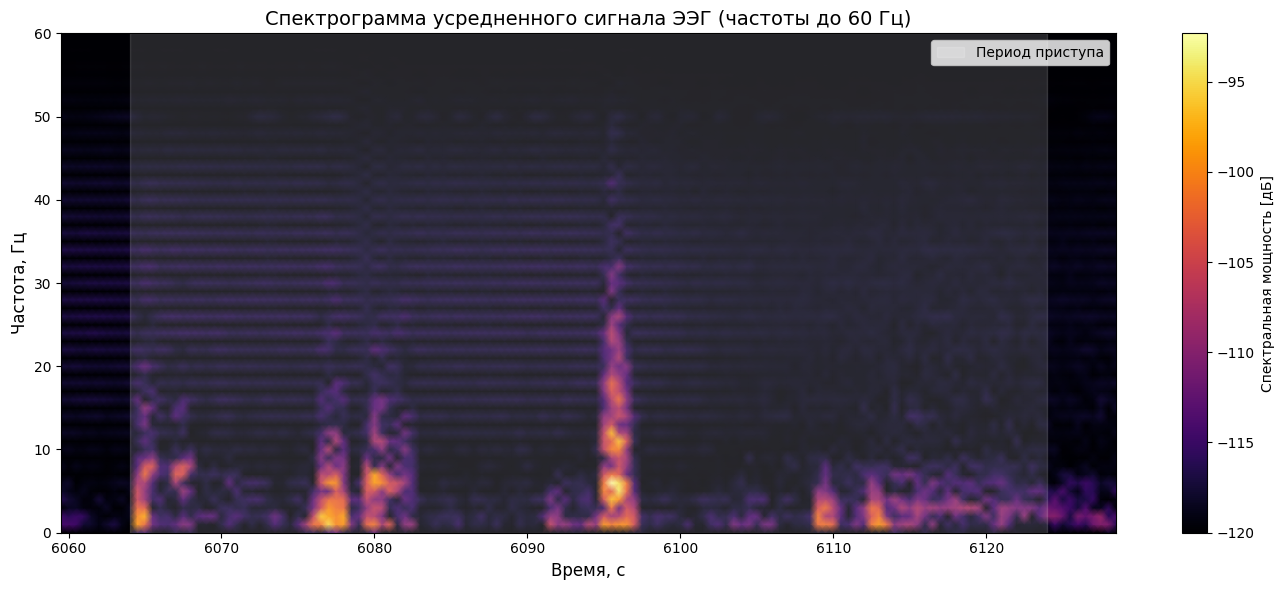

In [27]:
print("Построение спектрограммы...")
f, t_spec, Sxx = spectrogram(filtered_signal, fs, nperseg=256, noverlap=128)

# Преобразуем относительное время спектрограммы в абсолютное
t_spec_absolute = t_spec + plot_start

# --- Рисунок 2: Спектрограмма ---
plt.figure(figsize=(14, 6))
plt.pcolormesh(t_spec_absolute, f, 10 * np.log10(Sxx + 1e-12),
               shading='gouraud', cmap='inferno')
plt.axvspan(seizure_start, seizure_end, color='white', alpha=0.15, label='Период приступа')
plt.ylabel('Частота, Гц', fontsize=12)
plt.xlabel('Время, с', fontsize=12)
plt.title('Спектрограмма усредненного сигнала ЭЭГ (частоты до 60 Гц)', fontsize=14)
plt.colorbar(label='Спектральная мощность [дБ]')
plt.ylim(0, cutoff_freq)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Построение скейлограммы (вейвлет-преобразование)...
Форма матрицы вейвлет-коэффициентов: (127, 17920)


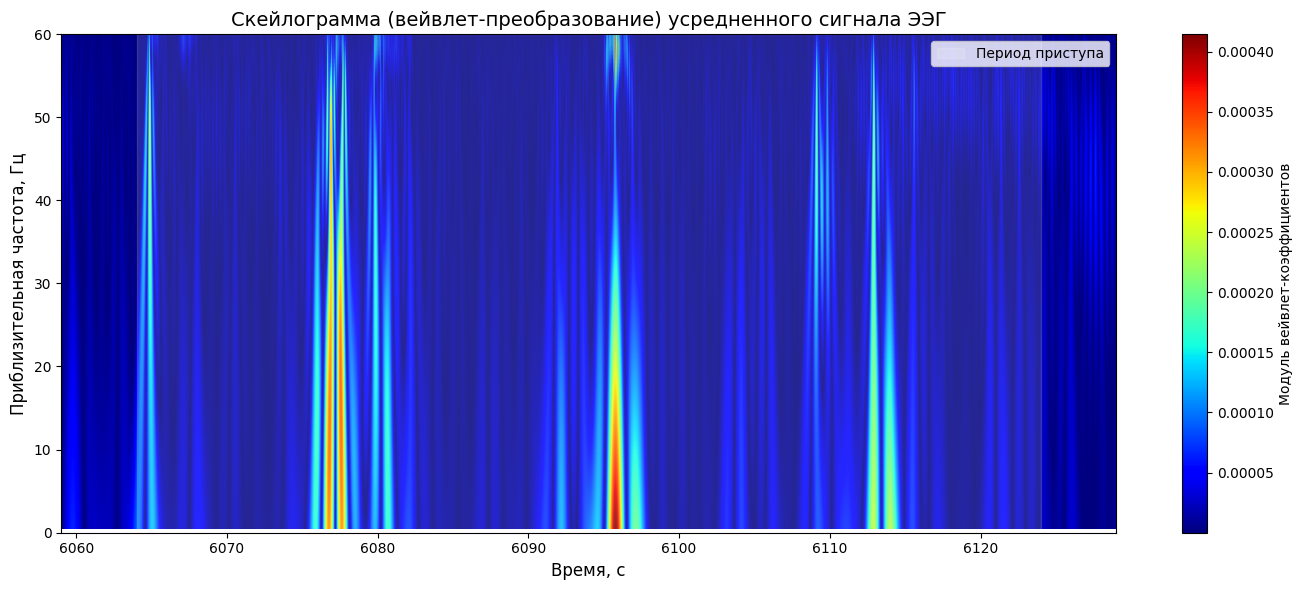

✅ Все расчеты и визуализации завершены!


In [28]:
print("Построение скейлограммы (вейвлет-преобразование)...")
wavelet = 'mexh'
scales = np.arange(1, 128)

# Непрерывное вейвлет-преобразование
coeffs, freqs_wav = pywt.cwt(filtered_signal, scales, wavelet, sampling_period=1/fs)
print(f"Форма матрицы вейвлет-коэффициентов: {coeffs.shape}")

# Создаем правильные временные координаты
wavelet_times = np.linspace(plot_start, plot_end, len(filtered_signal))

# --- Рисунок 3: Скейлограмма ---
plt.figure(figsize=(14, 6))
extent = [wavelet_times[0], wavelet_times[-1], freqs_wav[-1], freqs_wav[0]]
plt.imshow(np.abs(coeffs), extent=extent, aspect='auto', cmap='jet', origin='upper')
plt.axvspan(seizure_start, seizure_end, color='white', alpha=0.15, label='Период приступа')
plt.ylabel('Приблизительная частота, Гц', fontsize=12)
plt.xlabel('Время, с', fontsize=12)
plt.title('Скейлограмма (вейвлет-преобразование) усредненного сигнала ЭЭГ', fontsize=14)
plt.colorbar(label='Модуль вейвлет-коэффициентов')
plt.legend(loc='upper right')
plt.ylim(0, 60)  # Ограничим до 60 Гц
plt.tight_layout()
plt.show()

print("✅ Все расчеты и визуализации завершены!")